In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [3]:
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

In [4]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
train['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [6]:
train['Sex'].value_counts(normalize=True)

Sex
male      0.647587
female    0.352413
Name: proportion, dtype: float64

In [7]:
train['Cabin'].value_counts(normalize=False)

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F2             3
D              3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [8]:
train.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [9]:
train.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

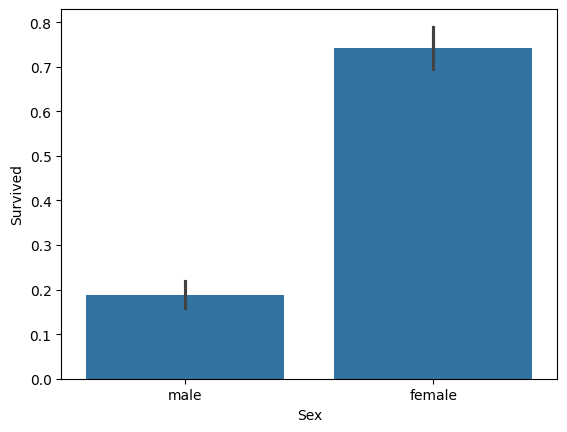

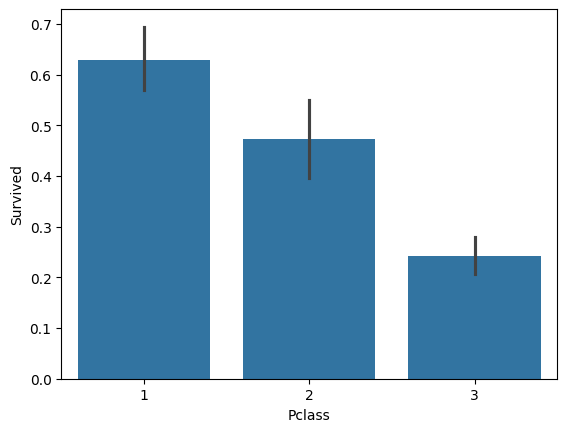

In [10]:
sns.barplot(x='Sex', y='Survived', data=train)
plt.show()

sns.barplot(x='Pclass', y='Survived', data=train)
plt.show()

In [11]:
train['Age'].fillna(train['Age'].median(), inplace=True)
test['Age'].fillna(test['Age'].median(), inplace=True)

train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)
test['Embarked'].fillna(test['Embarked'].mode()[0], inplace=True)

test['Fare'].fillna(test['Fare'].median(), inplace=True)

/tmp/ipykernel_16/3421866796.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Age'].fillna(train['Age'].median(), inplace=True)
/tmp/ipykernel_16/3421866796.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [12]:
le = LabelEncoder()

train['Sex'] = le.fit_transform(train['Sex'])
test['Sex'] = le.transform(test['Sex'])

train['Embarked'] = le.fit_transform(train['Embarked'])
test['Embarked'] = le.transform(test['Embarked'])

In [13]:
# --- Feature engineering ---

# Family features
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1

train['IsAlone'] = (train['FamilySize'] == 1).astype(int)
test['IsAlone'] = (test['FamilySize'] == 1).astype(int)

# Title extraction (use raw string for regex)
train['Title'] = train['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
test['Title'] = test['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Normalize titles
common_titles = ['Mr', 'Miss', 'Mrs', 'Master']
train['Title'] = train['Title'].apply(lambda x: x if x in common_titles else 'Other')
test['Title'] = test['Title'].apply(lambda x: x if x in common_titles else 'Other')

# Consistent encoding (no LabelEncoder issues)
title_map = {'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Other': 4}

train['Title'] = train['Title'].map(title_map)
test['Title'] = test['Title'].map(title_map)

In [14]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,Title
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,2,2,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,0,2,0,2
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,2,1,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,2,2,0,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,2,1,1,0


In [15]:
features = [
    'Pclass',
    'Sex',
    'Age',
    'Fare',
    'Embarked',
    'FamilySize',
    'IsAlone',
    'Title'
]

x = train[features]
y = train['Survived']

x_test = test[features]

In [16]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth = 5,
    random_state=42
)
model.fit(x,y)

RandomForestClassifier(max_depth=5, random_state=42)

In [17]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

model.fit(x_train, y_train)
preds = model.predict(x_val)

accuracy_score(y_val, preds)

0.8268156424581006

In [18]:
test_preds = model.predict(x_test)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_preds
})

submission.to_csv('/kaggle/working/submission.csv', index=False)

In [19]:
from sklearn.ensemble import GradientBoostingClassifier

grad_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

grad_model.fit(x_train, y_train)

val_preds = grad_model.predict(x_val)
print("Validation accuracy:", accuracy_score(y_val, val_preds))

Validation accuracy: 0.8100558659217877


In [20]:
from sklearn.linear_model import LogisticRegression

l_model = LogisticRegression(max_iter=1000)

l_model.fit(x_train, y_train)
val_preds = grad_model.predict(x_val)
print("Validation accuracy:", accuracy_score(y_val, val_preds))

Validation accuracy: 0.8100558659217877


In [21]:
train['AgeBin']=pd.cut(train['Age'], bins=[0, 12, 18, 35, 60, 100], labels=False)
test['AgeBin']=pd.cut(test['Age'], bins=[0, 12, 18, 35, 60, 100], labels=False)

In [22]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,Title,AgeBin
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,2,2,0,0,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,0,2,0,2,3
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,2,1,1,1,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,2,2,0,2,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,2,1,1,0,2


In [23]:
features = [
    'Pclass',
    'Sex',
    'AgeBin',
    'Fare',
    'Embarked',
    'FamilySize',
    'IsAlone',
    'Title'
]

x = train[features]
y = train['Survived']

x_test = test[features]

In [24]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth = 6,
    random_state=42
)
model.fit(x,y)

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

model.fit(x_train, y_train)
preds = model.predict(x_val)

accuracy_score(y_val, preds)

0.8324022346368715

In [25]:
from sklearn.ensemble import GradientBoostingClassifier

grad_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

grad_model.fit(x_train, y_train)

val_preds = grad_model.predict(x_val)
print("Validation accuracy:", accuracy_score(y_val, val_preds))

Validation accuracy: 0.8268156424581006


In [26]:
test_preds = model.predict(x_test)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_preds
})

submission.to_csv('/kaggle/working/submission.csv', index=False)